In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [4]:
df = pd.read_csv("telco_data.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 7043
Number of columns: 21


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            6293 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           6043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            4543 non-null   float64
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   6043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       5543 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,4543.000000,5543.000000
mean,0.162147,32.546555,64.876403
std,0.368612,24.505519,30.101331
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.750000
50%,0.000000,29.000000,70.550000
75%,0.000000,56.000000,89.925000
max,1.000000,72.000000,118.600000


In [9]:
missing_values = df.isnull().sum()
print("Missing values by column:")
print(missing_values)


Missing values by column:
customerID             0
gender               750
SeniorCitizen          0
Partner             1000
Dependents             0
tenure              2500
PhoneService           0
MultipleLines          0
InternetService     1000
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV         1500
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges      1500
TotalCharges           0
Churn                  0
dtype: int64


In [10]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

missing_summary = missing_summary[missing_summary["Missing Values"] > 0]

missing_summary.sort_values(
    by="Missing Percentage",
    ascending=False
)

,Missing Values,Missing Percentage
tenure,2500,35.496237
StreamingTV,1500,21.297742
MonthlyCharges,1500,21.297742
Partner,1000,14.198495
InternetService,1000,14.198495
gender,750,10.648871


In [11]:
df.nunique().sort_values()

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
PhoneService           2
PaperlessBilling       2
Churn                  2
MultipleLines          3
TechSupport            3
StreamingTV            3
OnlineBackup           3
DeviceProtection       3
StreamingMovies        3
Contract               3
OnlineSecurity         3
InternetService        3
PaymentMethod          4
tenure                73
MonthlyCharges      1489
TotalCharges        6531
customerID          7043
dtype: int64

In [12]:
missing_per_row = df.isnull().sum(axis=1)

missing_per_row.value_counts().sort_index()

0    4543
1    1000
3     500
5     250
6     750
Name: count, dtype: int64

In [13]:
customers_with_missing = (missing_per_row > 0).sum()

print("Customers with at least one missing value:", customers_with_missing)
print("Percentage of customers affected:",
      round(customers_with_missing / len(df) * 100, 2), "%")


Customers with at least one missing value: 2500
Percentage of customers affected: 35.5 %


In [14]:
missing_matrix = df.isnull().astype(int)

missing_matrix.corr()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,NaN,1.000000,NaN,0.848649,NaN,0.465375,NaN,NaN,0.848649,NaN,...,NaN,NaN,0.663634,NaN,NaN,NaN,NaN,0.663634,NaN,NaN
SeniorCitizen,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Partner,NaN,0.848649,NaN,1.000000,NaN,0.548372,NaN,NaN,1.000000,NaN,...,NaN,NaN,0.781989,NaN,NaN,NaN,NaN,0.781989,NaN,NaN
Dependents,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,NaN,0.465375,NaN,0.548372,NaN,1.000000,NaN,NaN,0.548372,NaN,...,NaN,NaN,0.701253,NaN,NaN,NaN,NaN,0.701253,NaN,NaN
PhoneService,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,NaN,0.848649,NaN,1.000000,NaN,0.548372,NaN,NaN,1.000000,NaN,...,NaN,NaN,0.781989,NaN,NaN,NaN,NaN,0.781989,NaN,NaN
OnlineSecurity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
column_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Unique Values": df.nunique().values,
    "Missing Values": df.isnull().sum().values
})

column_summary

,Column,Data Type,Unique Values,Missing Values
0,customerID,object,7043,0
1,gender,object,2,750
2,SeniorCitizen,int64,2,0
3,Partner,object,2,1000
4,Dependents,object,2,0
5,tenure,float64,73,2500
6,PhoneService,object,2,0
7,MultipleLines,object,3,0
8,InternetService,object,3,1000
9,OnlineSecurity,object,3,0


In [16]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [17]:
rows_with_missing = df[missing_per_row > 0]

rows_with_missing.head(10)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
8,7892-POOKP,Female,0,Yes,No,NaN,Yes,Yes,Fiber optic,No,...,Yes,Yes,NaN,Yes,Month-to-month,Yes,Electronic check,NaN,3046.05,Yes
12,8091-TTVAX,Male,0,Yes,No,NaN,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,No,Credit card (automatic),100.35,5681.1,No
14,5129-JLPIS,Male,0,No,No,NaN,Yes,No,Fiber optic,Yes,...,Yes,Yes,NaN,Yes,Month-to-month,Yes,Electronic check,NaN,2686.05,No
15,3655-SNQYZ,Female,0,Yes,Yes,NaN,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,NaN,Yes,Two year,No,Credit card (automatic),NaN,7895.15,No
17,9959-WOFKT,NaN,0,NaN,Yes,NaN,Yes,Yes,NaN,Yes,...,Yes,No,NaN,Yes,Two year,No,Bank transfer (automatic),NaN,7382.25,No
19,4183-MYFRB,NaN,0,NaN,No,NaN,Yes,No,NaN,No,...,Yes,No,NaN,Yes,Month-to-month,Yes,Electronic check,NaN,1862.9,No
23,3638-WEABW,NaN,0,NaN,No,NaN,Yes,Yes,NaN,No,...,No,Yes,NaN,No,Two year,Yes,Credit card (automatic),NaN,3505.1,No
26,6467-CHFZW,Male,0,Yes,Yes,NaN,Yes,Yes,Fiber optic,No,...,No,No,NaN,Yes,Month-to-month,Yes,Electronic check,NaN,4749.15,Yes
29,8773-HHUOZ,Female,0,No,Yes,NaN,Yes,No,DSL,No,...,No,No,Yes,Yes,Month-to-month,Yes,Mailed check,64.70,1093.1,Yes
30,3841-NFECX,Female,1,Yes,No,NaN,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,No,No,Two year,Yes,Credit card (automatic),96.35,6766.95,No


In [18]:
missing_per_row.value_counts().sort_index()


0    4543
1    1000
3     500
5     250
6     750
Name: count, dtype: int64

In [19]:
string_columns = df.select_dtypes(include="object").columns

blank_counts = {}

for column in string_columns:
    blank_counts[column] = df[column].astype(str).str.strip().eq("").sum()

pd.Series(blank_counts).sort_values(ascending=False)

TotalCharges        11
customerID           0
gender               0
Partner              0
PhoneService         0
Dependents           0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
MultipleLines        0
DeviceProtection     0
TechSupport          0
StreamingMovies      0
StreamingTV          0
Contract             0
PaperlessBilling     0
PaymentMethod        0
Churn                0
dtype: int64

In [20]:
df_clean = df.copy()

# Convert TotalCharges to numeric.
# Invalid or blank values will become NaN.

df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"],
    errors="coerce"
)

print("TotalCharges data type after conversion:")
print(df_clean["TotalCharges"].dtype)

print("\nMissing values after conversion:")
print(df_clean.isnull().sum().sort_values(ascending=False))

TotalCharges data type after conversion:
float64

Missing values after conversion:
tenure              2500
StreamingTV         1500
MonthlyCharges      1500
InternetService     1000
Partner             1000
gender               750
TotalCharges          11
customerID             0
SeniorCitizen          0
Dependents             0
OnlineSecurity         0
PhoneService           0
MultipleLines          0
TechSupport            0
DeviceProtection       0
OnlineBackup           0
StreamingMovies        0
PaperlessBilling       0
Contract               0
PaymentMethod          0
Churn                  0
dtype: int64


In [23]:
numerical_columns = df_clean.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = df_clean.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical columns:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [25]:
for column in numerical_columns:
    if df_clean[column].isnull().sum() > 0:
        df_clean[column] = df_clean[column].fillna(
            df_clean[column].median()
        )

for column in categorical_columns:
    if df_clean[column].isnull().sum() > 0:
        df_clean[column] = df_clean[column].fillna("Unknown")

In [26]:

remaining_missing = df_clean.isnull().sum()

print("Remaining missing values:")
print(remaining_missing[remaining_missing > 0])

print("\nDataset shape after cleaning:", df_clean.shape)

Remaining missing values:
Series([], dtype: int64)

Dataset shape after cleaning: (7043, 21)


In [56]:
sns.countplot(
    data=df_clean,
    x="Churn",
    ax=axes[0, 0],
    palette="Set2"
)

C:\Users\sonus\AppData\Local\Temp\ipykernel_28164\4003285848.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


<Axes: title={'center': 'Customer Churn Distribution'}, xlabel='Churn Status', ylabel='Number of Customers'>

In [28]:
churn_summary = df_clean["Churn"].value_counts()

churn_percentage = (
    df_clean["Churn"].value_counts(normalize=True) * 100
).round(2)

churn_table = pd.DataFrame({
    "Customer Count": churn_summary,
    "Percentage": churn_percentage
})

churn_table


,Customer Count,Percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


In [29]:

numerical_eda = df_clean.groupby("Churn")[
    ["tenure", "MonthlyCharges", "TotalCharges"]
].mean().round(2)

numerical_eda

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,34.48,63.38,2552.88
Yes,22.44,73.57,1531.80


In [30]:
contract_churn = pd.crosstab(
    df_clean["Contract"],
    df_clean["Churn"],
    normalize="index"
) * 100

contract_churn.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


In [31]:
internet_churn = pd.crosstab(
    df_clean["InternetService"],
    df_clean["Churn"],
    normalize="index"
) * 100

internet_churn.round(2)

Churn,No,Yes
InternetService,,
DSL,80.74,19.26
Fiber optic,58.50,41.50
No,92.39,7.61
Unknown,73.50,26.50


In [32]:
statistical_summary = df_clean[
    ["tenure", "MonthlyCharges", "TotalCharges"]
].describe().T

statistical_summary

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,31.287662,19.753692,0.00,19.000,29.000,41.00,72.0
MonthlyCharges,7043.0,66.084751,26.804520,18.25,49.450,70.550,84.85,118.6
TotalCharges,7043.0,2281.916928,2265.270398,18.80,402.225,1397.475,3786.60,8684.8


In [33]:
numerical_features = ["tenure", "MonthlyCharges", "TotalCharges"]

iqr_results = []

for column in numerical_features:
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[column] < lower_bound) |
        (df_clean[column] > upper_bound)
    ]

    iqr_results.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers),
        "Outlier Percentage": round(
            len(outliers) / len(df_clean) * 100, 2
        )
    })

iqr_summary = pd.DataFrame(iqr_results)

iqr_summary

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,tenure,19.000,41.00,22.000,-14.0000,74.0000,0,0.0
1,MonthlyCharges,49.450,84.85,35.400,-3.6500,137.9500,0,0.0
2,TotalCharges,402.225,3786.60,3384.375,-4674.3375,8863.1625,0,0.0


In [34]:
central_tendency = df_clean[
    ["tenure", "MonthlyCharges", "TotalCharges"]
].agg(["mean", "median"]).T

central_tendency

,mean,median
tenure,31.287662,29.000
MonthlyCharges,66.084751,70.550
TotalCharges,2281.916928,1397.475


In [35]:
X = df_clean.drop(columns=["Churn", "customerID"])
y = df_clean["Churn"].map({"No": 0, "Yes": 1})

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (7043, 19)
Target shape: (7043,)


In [38]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)



Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining churn rate:", round(y_train.mean() * 100, 2), "%")
print("Testing churn rate:", round(y_test.mean() * 100, 2), "%")

Training samples: 5634
Testing samples: 1409

Training churn rate: 26.54 %
Testing churn rate: 26.54 %


In [41]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# Train the model

logistic_model.fit(X_train, y_train)
print("Logistic Regression model trained successfully.")


Logistic Regression model trained successfully.


In [42]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Generate predictions

y_pred = logistic_model.predict(X_test)

# Calculate evaluation metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Logistic Regression Performance")
print("-" * 35)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Performance
-----------------------------------
Accuracy : 0.7906
Precision: 0.6295
Recall   : 0.5134
F1-Score : 0.5655

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



Confusion Matrix:
[[922 113]
 [182 192]]


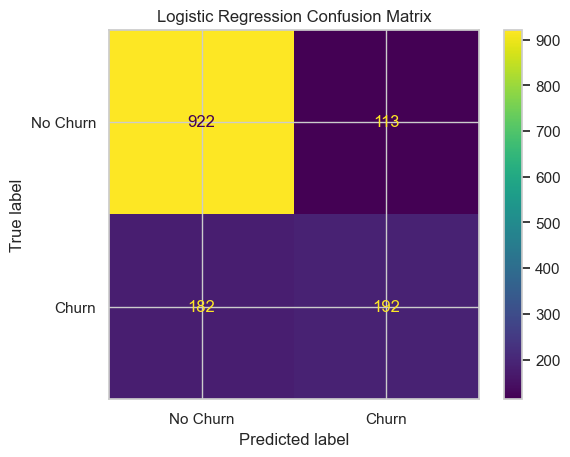

In [43]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
).plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create regression features and target

X_reg = df_clean.drop(columns=["TotalCharges", "customerID"])
y_reg = df_clean["TotalCharges"]

# Identify numerical and categorical features

reg_numerical_features = X_reg.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

reg_categorical_features = X_reg.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:", reg_numerical_features)
print("Categorical features:", reg_categorical_features)

Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [46]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_reg_train))
print("Testing samples:", len(X_reg_test))

Training samples: 5634
Testing samples: 1409


In [47]:
reg_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            reg_numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            reg_categorical_features
        )
    ]
)

linear_model = Pipeline(
    steps=[
        ("preprocessor", reg_preprocessor),
        ("regressor", LinearRegression())
    ]
)

# Train the model

linear_model.fit(X_reg_train, y_reg_train)

print("Linear Regression model trained successfully.")


Linear Regression model trained successfully.


In [48]:
y_reg_pred = linear_model.predict(X_reg_test)

# Evaluate the model

mae = mean_absolute_error(y_reg_test, y_reg_pred)
mse = mean_squared_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_reg_test, y_reg_pred)

print("Linear Regression Performance")
print("-" * 35)
print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

Linear Regression Performance
-----------------------------------
MAE : 1118.64
MSE : 2422185.89
RMSE: 1556.34
R²  : 0.5341


C:\Users\sonus\AppData\Roaming\Python\Python314\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


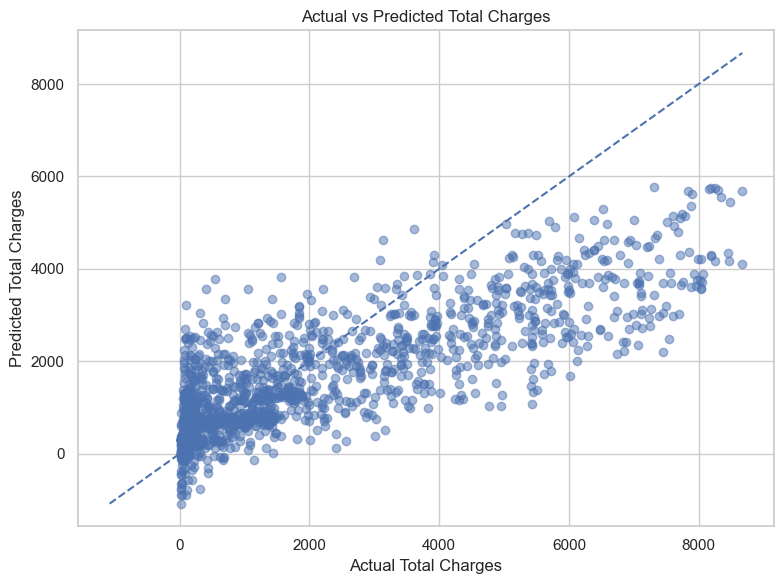

In [49]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_reg_test,
    y_reg_pred,
    alpha=0.5
)

# Perfect prediction reference line

min_value = min(y_reg_test.min(), y_reg_pred.min())
max_value = max(y_reg_test.max(), y_reg_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Total Charges")
plt.ylabel("Predicted Total Charges")
plt.title("Actual vs Predicted Total Charges")

plt.tight_layout()
plt.show()

In [50]:
preprocessor_fitted = logistic_model.named_steps["preprocessor"]
classifier = logistic_model.named_steps["classifier"]

feature_names = preprocessor_fitted.get_feature_names_out()

coefficients = classifier.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Add absolute coefficient magnitude

feature_importance["Absolute Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

# Display strongest features

feature_importance = feature_importance.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute Coefficient
29,cat__Contract_Two year,-1.611208,1.611208
12,cat__InternetService_Fiber optic,0.912529,0.912529
28,cat__Contract_One year,-0.856997,0.856997
3,num__TotalCharges,-0.568502,0.568502
13,cat__InternetService_No,0.537271,0.537271
32,cat__PaymentMethod_Electronic check,0.453298,0.453298
9,cat__PhoneService_Yes,-0.439430,0.439430
16,cat__OnlineSecurity_Yes,-0.434489,0.434489
27,cat__StreamingMovies_Yes,0.379827,0.379827
30,cat__PaperlessBilling_Yes,0.370309,0.370309


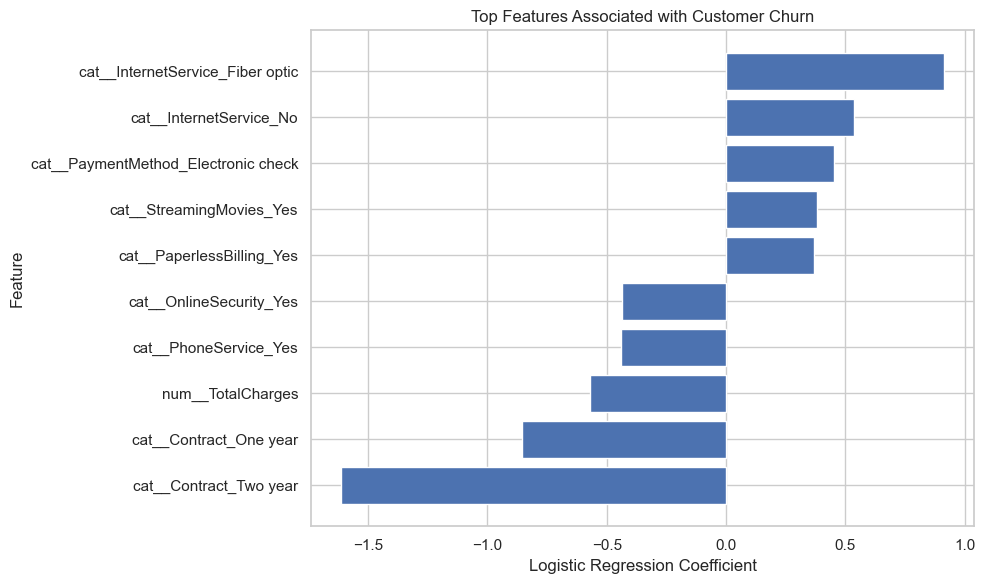

In [51]:
top_features = feature_importance.head(10).sort_values(
    by="Coefficient"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top Features Associated with Customer Churn")

plt.tight_layout()
plt.show()

In [52]:
churn_probability = logistic_model.predict_proba(X_test)[:, 1]

risk_insights = X_test.copy()

risk_insights["Actual_Churn"] = y_test.values
risk_insights["Churn_Probability"] = churn_probability

# Assign risk categories

risk_insights["Risk_Category"] = pd.cut(
    risk_insights["Churn_Probability"],
    bins=[-0.01, 0.30, 0.60, 1.00],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

# Display risk distribution

risk_distribution = (
    risk_insights["Risk_Category"]
    .value_counts()
    .sort_index()
)

risk_distribution

Risk_Category
Low Risk       862
Medium Risk    348
High Risk      199
Name: count, dtype: int64

In [53]:
risk_percentage = (
    risk_insights["Risk_Category"]
    .value_counts(normalize=True)
    .sort_index() * 100
).round(2)

risk_summary = pd.DataFrame({
    "Customer Count": risk_distribution,
    "Percentage": risk_percentage
})

risk_summary

,Customer Count,Percentage
Risk_Category,,
Low Risk,862,61.18
Medium Risk,348,24.70
High Risk,199,14.12


In [54]:
risk_churn_rate = (
    risk_insights.groupby("Risk_Category", observed=True)["Actual_Churn"]
    .mean() * 100
)

risk_churn_rate.round(2)


Risk_Category
Low Risk       11.14
Medium Risk    39.94
High Risk      69.85
Name: Actual_Churn, dtype: float64

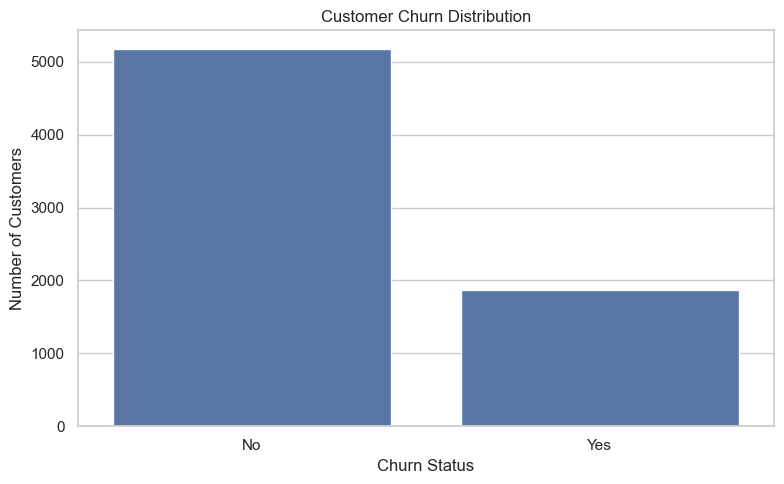

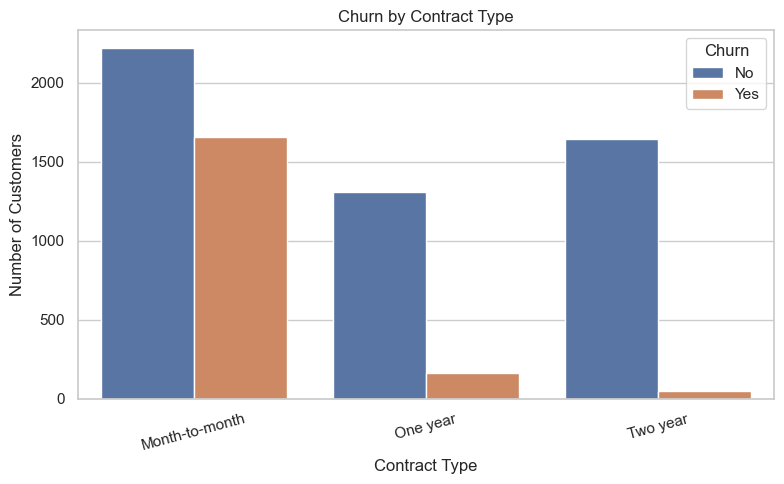

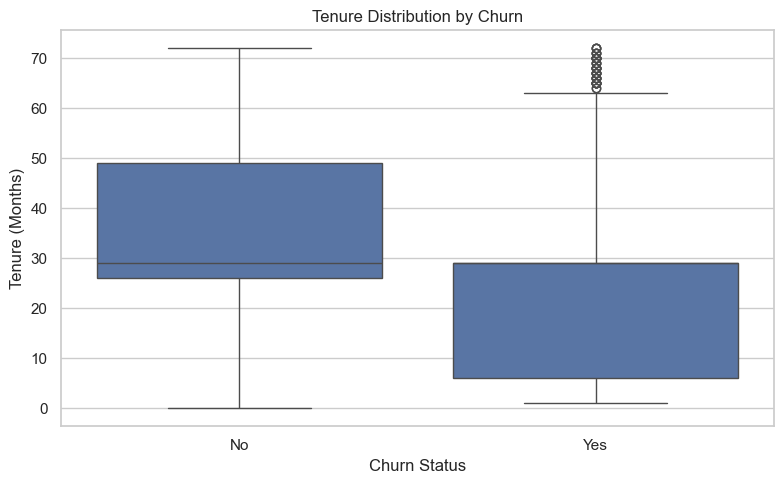

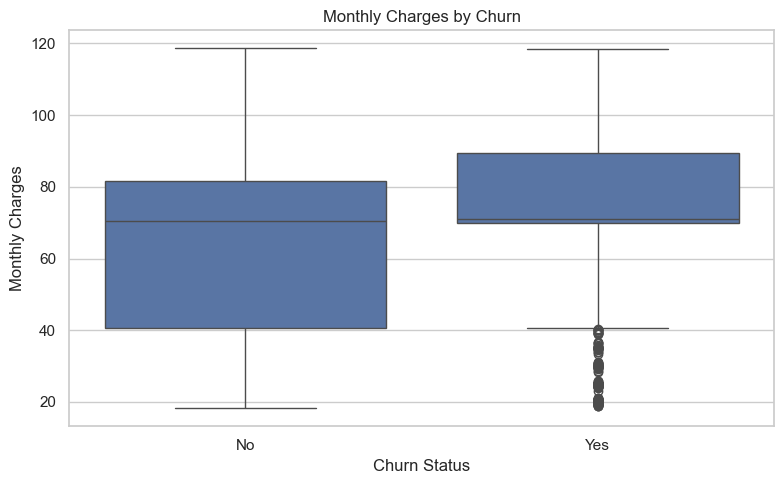

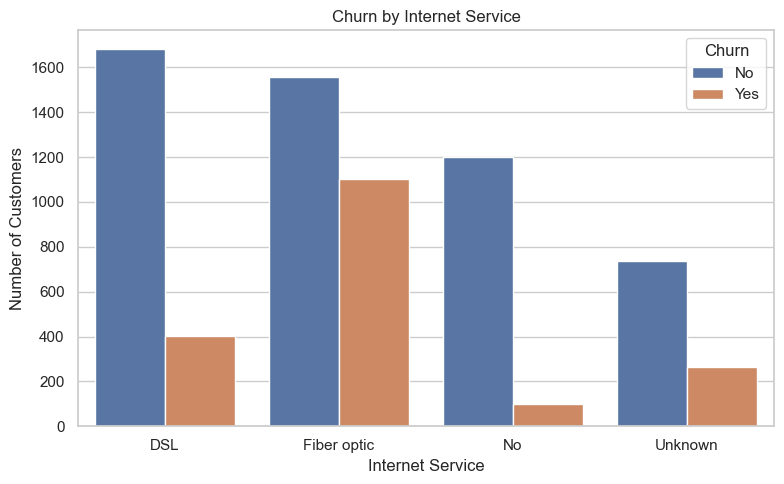

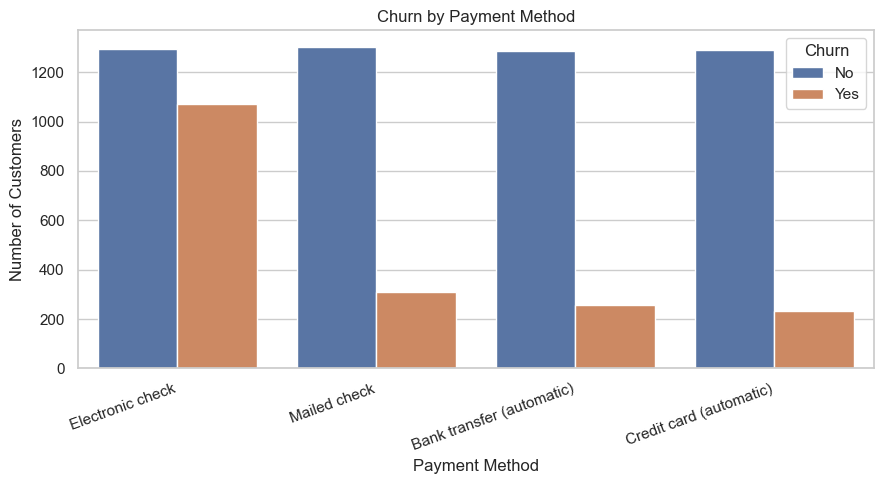

All visualizations saved successfully!


In [55]:
import os

os.makedirs("../visualizations", exist_ok=True)

# 1. Customer Churn Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("../visualizations/01_customer_churn_distribution.png", dpi=300)
plt.show()


# 2. Churn by Contract Type
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../visualizations/02_churn_by_contract.png", dpi=300)
plt.show()


# 3. Tenure Distribution by Churn
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x="Churn", y="tenure")
plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn Status")
plt.ylabel("Tenure (Months)")
plt.tight_layout()
plt.savefig("../visualizations/03_tenure_by_churn.png", dpi=300)
plt.show()


# 4. Monthly Charges by Churn
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges by Churn")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.savefig("../visualizations/04_monthly_charges_by_churn.png", dpi=300)
plt.show()


# 5. Churn by Internet Service
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x="InternetService", hue="Churn")
plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("../visualizations/05_churn_by_internet_service.png", dpi=300)
plt.show()


# 6. Churn by Payment Method
plt.figure(figsize=(9, 5))
sns.countplot(data=df_clean, x="PaymentMethod", hue="Churn")
plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("../visualizations/06_churn_by_payment_method.png", dpi=300)
plt.show()

print("All visualizations saved successfully!")